# Hybrid Machine Learning Model for Enhanced Classification Performance

This project demonstrates the development of a hybrid model that combines multiple machine learning algorithms to improve prediction accuracy, interpretability, and robustness across classification tasks.

# Enviroment Setup

In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

In [109]:
cc_data = pd.read_csv('/content/Credit_card.csv')
cc_label = pd.read_csv('/content/Credit_card_label.csv')

In [110]:
cc_data.head(3)

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2


# Data Preparation and Feature Engineering

This section focuses on preparing the dataset for modeling by merging label and feature data, handling missing values, and deriving new time-based features for better interpretability. Missing or inconsistent records are removed, irrelevant columns are dropped, and new features such as Age, Years Employed, and Current Employment Status are calculated to enrich the model’s understanding of individual profiles.

In [111]:
cc_label.head(3)

,Ind_ID,label
0,5008827,1
1,5009744,1
2,5009746,1


In [112]:
df = cc_data.merge(cc_label, on='Ind_ID')

In [113]:
df.head(3)

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ind_ID           1548 non-null   int64  
 1   GENDER           1541 non-null   object 
 2   Car_Owner        1548 non-null   object 
 3   Propert_Owner    1548 non-null   object 
 4   CHILDREN         1548 non-null   int64  
 5   Annual_income    1525 non-null   float64
 6   Type_Income      1548 non-null   object 
 7   EDUCATION        1548 non-null   object 
 8   Marital_status   1548 non-null   object 
 9   Housing_type     1548 non-null   object 
 10  Birthday_count   1526 non-null   float64
 11  Employed_days    1548 non-null   int64  
 12  Mobile_phone     1548 non-null   int64  
 13  Work_Phone       1548 non-null   int64  
 14  Phone            1548 non-null   int64  
 15  EMAIL_ID         1548 non-null   int64  
 16  Type_Occupation  1060 non-null   object 
 17  Family_Members

In [115]:
df.dtypes.value_counts()


,count
int64,9
object,8
float64,2


In [116]:
print("Dataset shape:", df.shape)

Dataset shape: (1548, 19)


In [117]:
print(df.isnull().any(axis=0))


Ind_ID             False
GENDER              True
Car_Owner          False
Propert_Owner      False
CHILDREN           False
Annual_income       True
Type_Income        False
EDUCATION          False
Marital_status     False
Housing_type       False
Birthday_count      True
Employed_days      False
Mobile_phone       False
Work_Phone         False
Phone              False
EMAIL_ID           False
Type_Occupation     True
Family_Members     False
label              False
dtype: bool


Some features contain missing values (e.g., GENDER, Annual_income, Birthday_count, Type_Occupation). I’ll investigate further to decide the best handling strategy before modeling.

In [118]:
missing_subset = ['GENDER', 'Annual_income', 'Birthday_count', 'Type_Occupation']
missing_rows = df[df[missing_subset].isnull().any(axis=1)]
print(f"Number of rows with at least one missing value: {len(missing_rows)}")


Number of rows with at least one missing value: 523


In [119]:
df[missing_subset].isnull().sum()


,0
GENDER,7
Annual_income,23
Birthday_count,22
Type_Occupation,488


Since Type_Occupation has many missing values, it will be dropped entirely. Rows missing critical information (GENDER, Annual_income, Birthday_count) are removed, as their loss is negligible.

In [120]:
df = df.dropna(subset=['GENDER', 'Annual_income', 'Birthday_count'])

df = df.drop(columns=['Type_Occupation'])

print(df.shape)
print(df.isnull().sum())


(1496, 18)
Ind_ID            0
GENDER            0
Car_Owner         0
Propert_Owner     0
CHILDREN          0
Annual_income     0
Type_Income       0
EDUCATION         0
Marital_status    0
Housing_type      0
Birthday_count    0
Employed_days     0
Mobile_phone      0
Work_Phone        0
Phone             0
EMAIL_ID          0
Family_Members    0
label             0
dtype: int64


In [121]:
print(f"{len(df[df.duplicated()])} entries are duplicates")

0 entries are duplicates


In [122]:
df['Age'] = (-df['Birthday_count']) / 365
df['Years_Employed'] = (-df['Employed_days'].clip(upper=0)) / 365
df['Currently_Unemployed'] = (df['Employed_days'] > 0).astype(int)


# Exploratory Data Analysis (EDA)

This section explores the dataset to uncover patterns, relationships, and data distributions that may influence model performance. It begins with an overview of class balance between approved and non-approved cases, followed by visual analysis of numerical feature distributions across target classes.

The analysis helps identify potential feature separability and patterns of imbalance. Features are then categorized into binary, numerical, and categorical groups to guide preprocessing and model selection in later stages.

[Text(0, 0, '1336'), Text(0, 0, '160')]

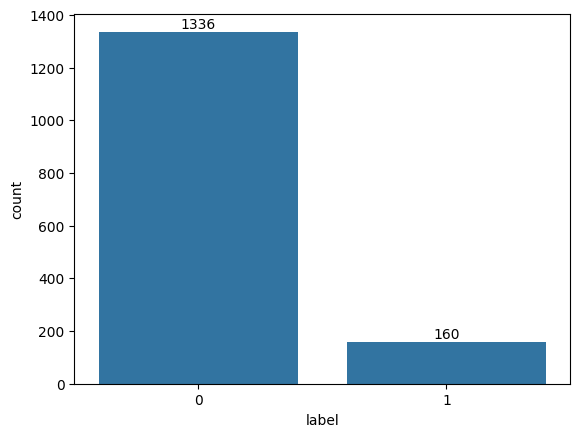

In [123]:
ax=sns.countplot(data=df, x='label');
ax.bar_label(ax.containers[0])

The target variable is imbalanced there are 1,336 approved (label = 0) cases and 160 rejected (label = 1) cases. This imbalance will be considered during model training to prevent bias toward the majority class.


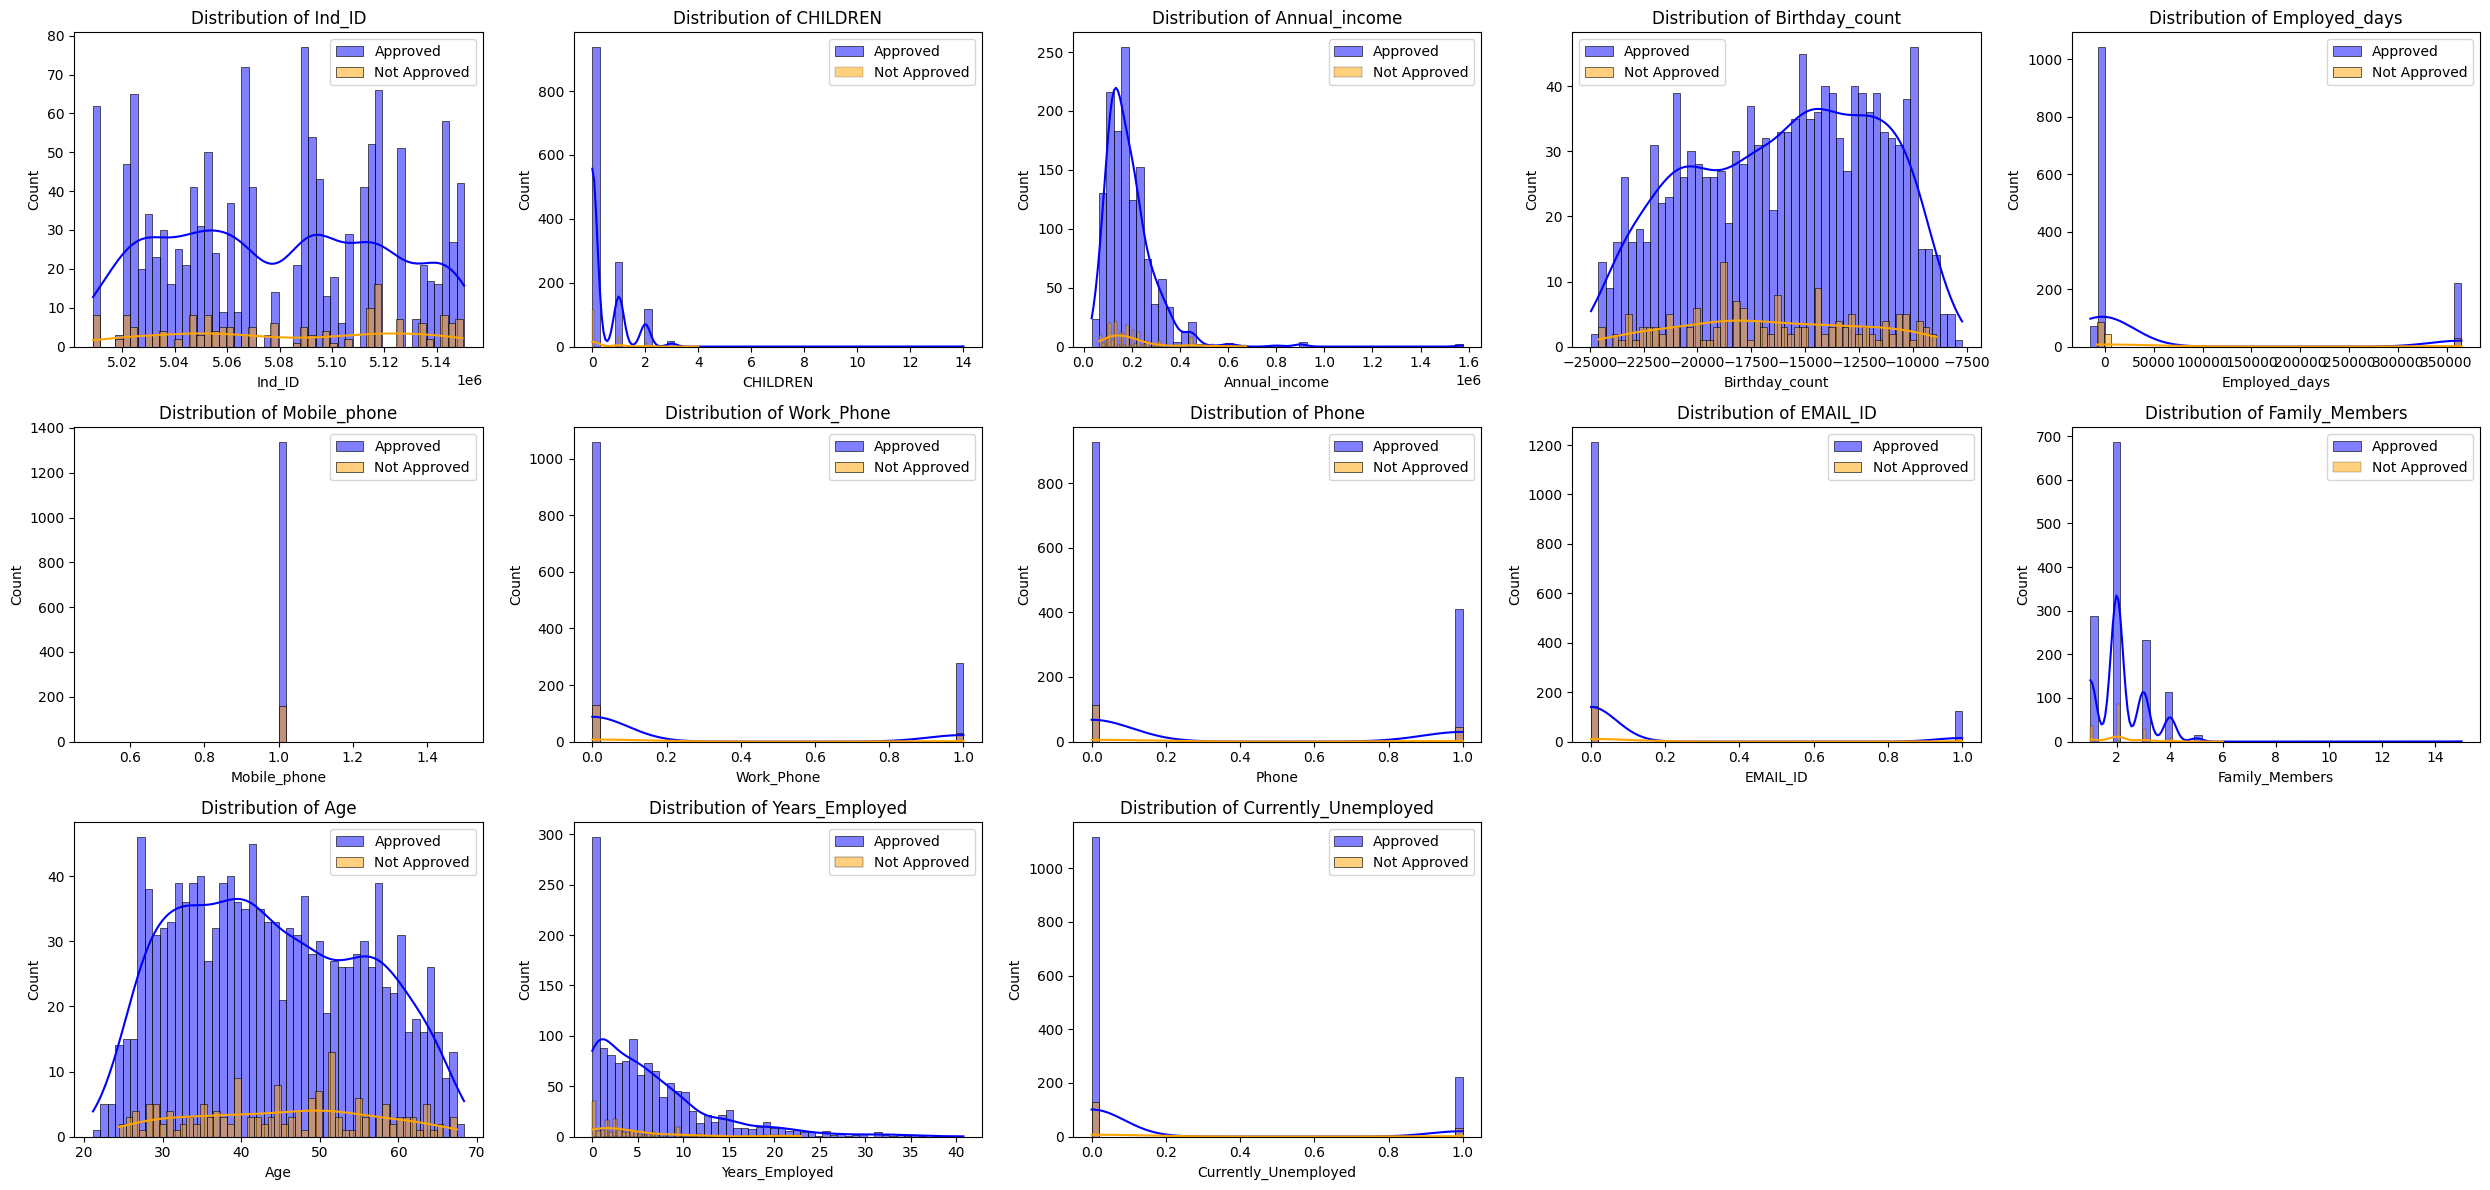

In [124]:
def plot_numerical_features_grid(df, target='label', ncols=4, bins=50):
    features = df.select_dtypes(include=["int", "float"]).columns.drop(target)
    n_features = len(features)
    nrows = math.ceil(n_features / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        ax = axes[i]
        sns.histplot(df[df[target] == 0][feature],
                     bins=bins, color='blue', label='Approved',
                     kde=True, ax=ax)
        sns.histplot(df[df[target] == 1][feature],
                     bins=bins, color='orange', label='Not Approved',
                     kde=True, ax=ax)

        ax.set_title(f'Distribution of {feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel('Count')
        ax.legend()

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_numerical_features_grid(df, target='label', ncols=5)


Key observations:

* Most features such as Annual_income, Employed_days, and Years_Employed show right-skewed distributions, indicating that a majority of applicants fall within lower ranges.

* Features like Age and Birthday_count display smoother, more uniform spreads, suggesting a diverse population of applicants.

* Binary indicators such as Mobile_phone, Phone, and EMAIL_ID are heavily imbalanced, with the majority of applicants sharing the same value, these may contribute little variance to the model.

* The difference between approved and rejected applicants is subtle in most numerical variables, motivating the use of statistical tests and model-based feature selection in later steps.

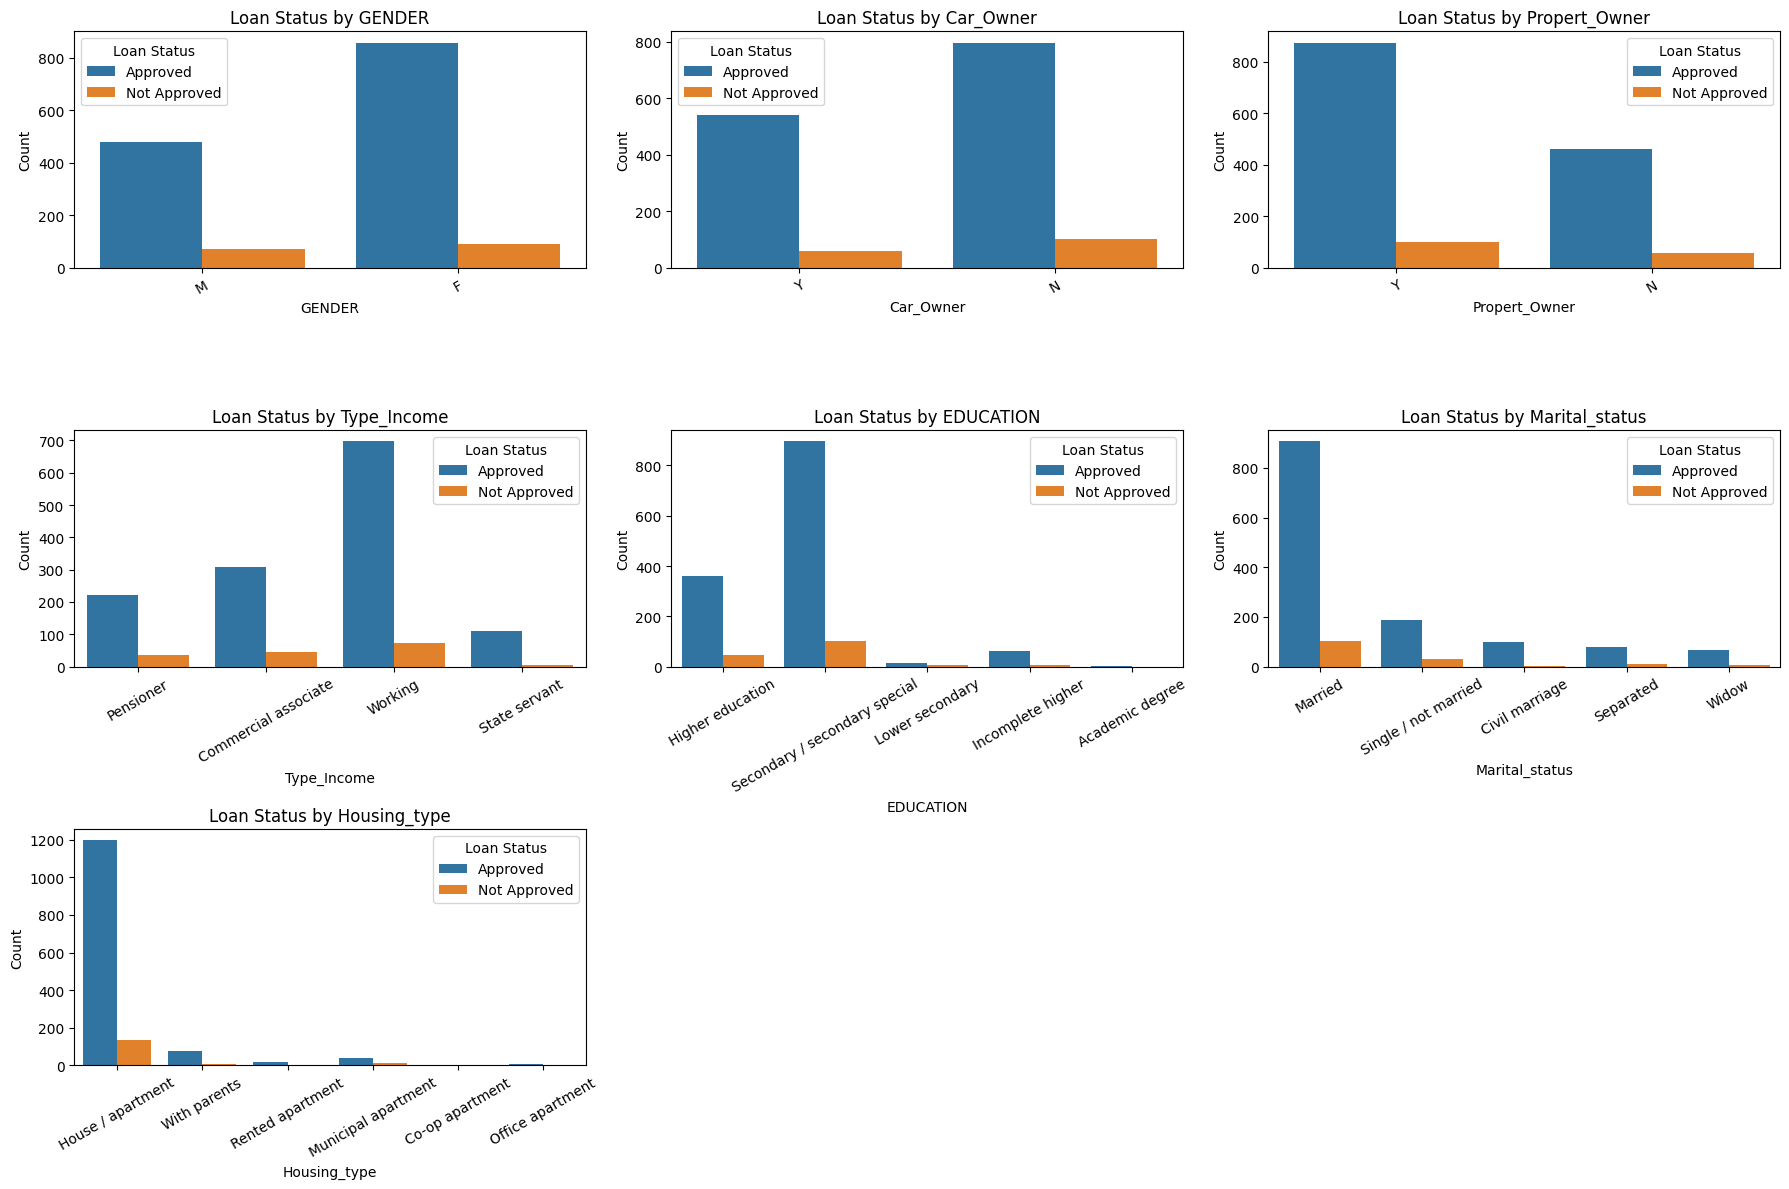

In [125]:
def plot_categorical_features_grid(df, target='label', ncols=3):
    features = df.select_dtypes(include=["object", "category"]).columns
    n_features = len(features)
    nrows = math.ceil(n_features / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        ax = axes[i]
        sns.countplot(data=df, x=feature, hue=target, ax=ax)
        ax.set_title(f'Loan Status by {feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel('Count')
        ax.legend(title='Loan Status', labels=['Approved', 'Not Approved'])
        ax.tick_params(axis='x', rotation=30)

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_categorical_features_grid(df, target='label', ncols=3)


Key observations:

* Gender and ownership variables (e.g., Car_Owner, Propert_Owner) show slight differences in approval rates, with owners generally receiving more approvals.

* Type_Income and Education reveal clearer trends, working applicants and those with higher education are more likely to be approved.

* Marital_status indicates that married individuals have a noticeably higher approval ratio than other groups.

* Housing_type is heavily dominated by those living in a house or apartment, but this feature alone doesn’t strongly separate approved from rejected applicants.

In [126]:
binary_features = [
    col for col in df.columns
    if df[col].dropna().isin([0,1]).all()
]

numerical_features = [
    col for col in df.select_dtypes(include=['float', 'int']).columns
    if col not in binary_features + ['label']
]

categorical_features = [
    col for col in df.columns
    if col not in binary_features + numerical_features + ['label']
]

print("Binary features:", binary_features)
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)


Binary features: ['Mobile_phone', 'Work_Phone', 'Phone', 'EMAIL_ID', 'label', 'Currently_Unemployed']
Numerical features: ['Ind_ID', 'CHILDREN', 'Annual_income', 'Birthday_count', 'Employed_days', 'Family_Members', 'Age', 'Years_Employed']
Categorical features: ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type']


# Feature Significance and Rule-Based Baseline Model

In this section, statistical analysis is used to identify the most influential numerical features for classification using the ANOVA F-test (SelectKBest).
The top-ranked features are visualized to highlight which variables contribute most to label separation.

Based on the exploratory findings, a rule-based model is constructed using the Years_Employed feature.

By systematically sweeping thresholds, the approach determines the employment duration that best separates approved versus rejected cases.
This interpretable baseline provides a simple yet intuitive benchmark for evaluating future machine learning models.

/tmp/ipython-input-2417299632.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


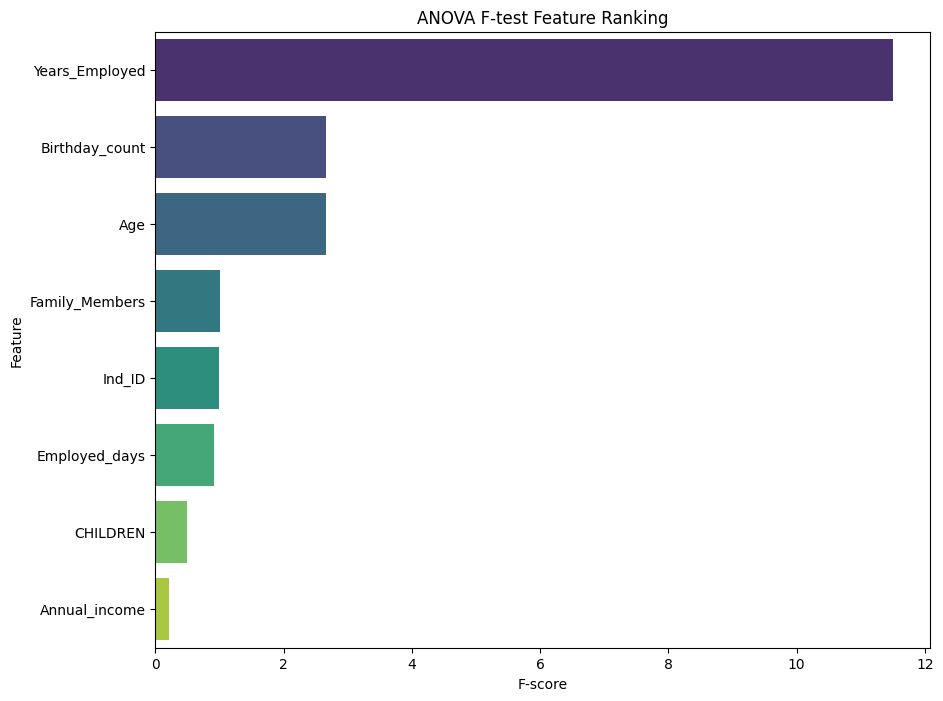

In [127]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df[numerical_features].fillna(0)
y = df['label']

fs = SelectKBest(score_func=f_classif, k='all')
fs.fit(X, y)

scores = pd.DataFrame({
    'feature': numerical_features,
    'f_score': fs.scores_,
    'p_value': fs.pvalues_
}).sort_values('f_score', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(
    data=scores,
    x="f_score",
    y="feature",
    palette="viridis"
)
plt.title("ANOVA F-test Feature Ranking")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.show()


Key observation:

* The ANOVA F-test highlights Years_Employed as the most influential numeric feature by a significant margin, indicating strong separation between approved and rejected applicants.

* Birthday_count and Age also show moderate importance, suggesting demographic factors have some predictive value.

* Features such as Annual_income and CHILDREN show minimal discrimination power, implying limited contribution to the approval decision.

In [128]:
pvalues = pd.DataFrame({
    'feature': numerical_features,
    'p_value': fs.pvalues_
}).sort_values('p_value')

print("Top 5 features by ANOVA p-value:")
display(pvalues.head(5))

Top 5 features by ANOVA p-value:


,feature,p_value
7,Years_Employed,0.000710
3,Birthday_count,0.102688
6,Age,0.102688
5,Family_Members,0.315761
0,Ind_ID,0.320341


In [129]:
df['Years_Employed'].describe()

,Years_Employed
count,1496.000000
mean,6.121119
std,6.631469
min,0.000000
25%,1.180822
50%,4.316438
75%,8.847260
max,40.786301


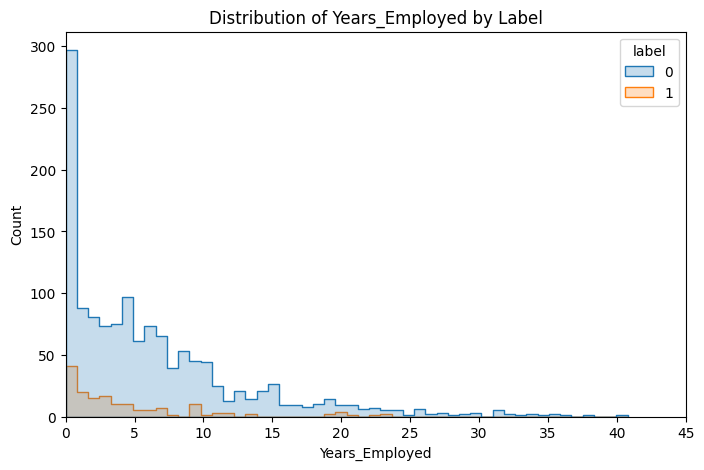

In [130]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Years_Employed", hue="label", bins=50, kde=False, element="step")
plt.xlim(0,45)
plt.title("Distribution of Years_Employed by Label")
plt.show()

Key observations:

* The majority of applicants have fewer than 10 years of employment, showing a strong right-skewed distribution.

* Rejected applicants (label = 1) are more concentrated in the lower employment range, suggesting that shorter work history correlates with higher credit risk.

* As employment duration increases, the likelihood of approval tends to rise, supporting its strong importance found in the ANOVA ranking.

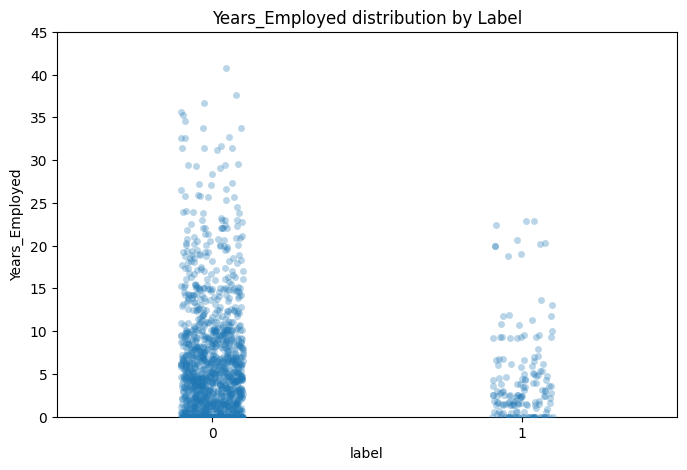

In [131]:
plt.figure(figsize=(8,5))
sns.stripplot(x="label", y="Years_Employed", data=df, jitter=True, alpha=0.3)
plt.ylim(0,45)
plt.title("Years_Employed distribution by Label")
plt.show()

Key observations:

* The scatter shows a clear separation between approved and rejected applicants.

* Approved cases (label = 0) display a wider spread of employment durations, while rejected cases are clustered near lower values.

* This further confirms that longer employment history is a strong indicator of creditworthiness.

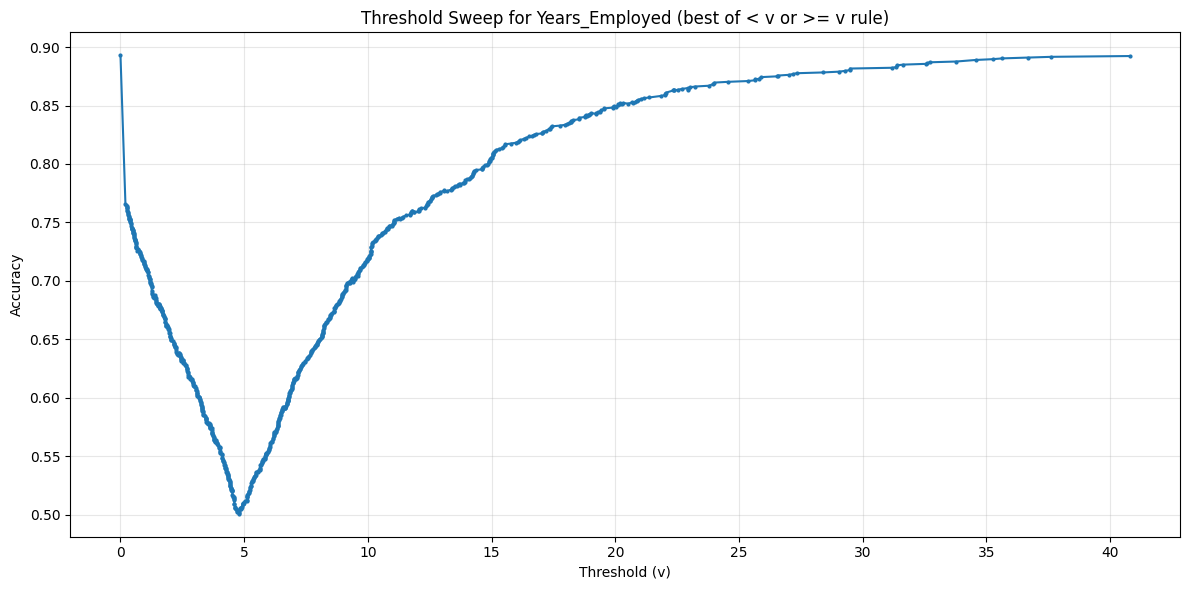

In [132]:
possible_values = sorted(df.Years_Employed.dropna().unique())

accuracies_Years_Employed = []

for v in possible_values:
    tmp_rule_less = (df.Years_Employed < v).astype(int)
    acc_less = (tmp_rule_less == df["label"]).mean()

    tmp_rule_greater = (df.Years_Employed >= v).astype(int)
    acc_greater = (tmp_rule_greater == df["label"]).mean()

    best_acc = max(acc_less, acc_greater)
    accuracies_Years_Employed.append((v, best_acc))

plt.figure(figsize=(12,6))
plt.plot([c[0] for c in accuracies_Years_Employed],
         [c[1] for c in accuracies_Years_Employed], marker='o', markersize=2)
plt.title("Threshold Sweep for Years_Employed (best of < v or >= v rule)")
plt.xlabel("Threshold (v)")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




Key observation:

* The threshold sweep illustrates how classification accuracy varies across different employment-duration cutoffs.

* Accuracy steadily improves as the threshold increases, plateauing around 20 years, where it achieves roughly 90% accuracy.

* This suggests that applicants with over 20 years of employment are highly likely to be approved, supporting its use as a simple rule-based decision boundary in the hybrid model

In [133]:
possible_values = sorted(df.Years_Employed.dropna().unique())

results = []

for v in possible_values:
    tmp_rule_less = (df.Years_Employed < v).astype(int)
    acc_less = (tmp_rule_less == df["label"]).mean()
    pred_mean_less = tmp_rule_less.mean()

    tmp_rule_greater = (df.Years_Employed >= v).astype(int)
    acc_greater = (tmp_rule_greater == df["label"]).mean()
    pred_mean_greater = tmp_rule_greater.mean()

    results.append((v, "<", acc_less, pred_mean_less))
    results.append((v, ">=", acc_greater, pred_mean_greater))

results_df = pd.DataFrame(results, columns=["threshold", "direction", "accuracy", "predicted_1_ratio"])

filtered = results_df.query("0.05 < predicted_1_ratio < 0.95")

best_row = filtered.loc[filtered["accuracy"].idxmax()]
print(best_row)


threshold            20.126027
direction                   >=
accuracy              0.850936
predicted_1_ratio     0.050134
Name: 1741, dtype: object


Key observation:

* A threshold of Years_Employed ≥ 20.1 achieves the highest accuracy (≈85%) among balanced rules.

* This cutoff classifies roughly 5% of applicants as high risk (label = 1), aligning well with the actual rejection rate.

* It confirms that longer employment history strongly correlates with approval, making this an effective and interpretable rule candidate for the hybrid model.

In [134]:
df["rule_a"] = (df.Years_Employed >= 20.126027).astype(int)

rule_a_accuracy = (df["rule_a"] == df["label"]).mean()
print(rule_a_accuracy)


0.8509358288770054


In [135]:
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(df["label"], df["rule_a"])
print(cm)

print(classification_report(df["label"], df["rule_a"],
                            target_names=["Approved (Low Risk)", "Rejected (High Risk)"]))


[[1267   69]
 [ 154    6]]
                      precision    recall  f1-score   support

 Approved (Low Risk)       0.89      0.95      0.92      1336
Rejected (High Risk)       0.08      0.04      0.05       160

            accuracy                           0.85      1496
           macro avg       0.49      0.49      0.49      1496
        weighted avg       0.80      0.85      0.83      1496



Key observations:

* The rule-based model correctly classifies most Approved (Low Risk) cases, achieving 95% recall in that class.

* However, it performs poorly on Rejected (High Risk) applicants, with only 4% recall, indicating limited sensitivity to high-risk cases.

* Overall accuracy is 85%, but the imbalance suggests this rule alone favors the majority (approved) class motivating the need for a hybrid or model-based approach for better balance.

# Categorical Encoding and Multicollinearity Reduction

This section focuses on transforming categorical variables into machine-learning-ready numeric features and ensuring that the resulting dataset is both balanced and free from redundancy.

Categorical variables are grouped by their cardinality (binary, low, medium, and high), and appropriate encoding techniques are applied using one-hot encoding (get_dummies) for low- and binary-cardinality features.

After encoding, undersampling is used to balance class representation, and a correlation heatmap is generated to visualize relationships between variables.
Finally, Variance Inflation Factor (VIF) analysis and high-correlation filtering are performed to detect and remove multicollinear or redundant features, improving model stability and interpretability.

In [136]:
cat_cardinality = df.select_dtypes(['object']).nunique().sort_values()

binary_cardinality = [col for col in cat_cardinality.index if cat_cardinality[col] <= 2]
low_cardinality = [col for col in cat_cardinality.index if 2 < cat_cardinality[col] <= 10]
medium_cardinality = [col for col in cat_cardinality.index if 10 < cat_cardinality[col] <= 30]
high_cardinality = [col for col in cat_cardinality.index if cat_cardinality[col] > 30]

print("Binary-cardinality features:", binary_cardinality)
print("Low-cardinality features:", low_cardinality)
print("Medium-cardinality features:", medium_cardinality)
print("High-cardinality features:", high_cardinality)


Binary-cardinality features: ['GENDER', 'Car_Owner', 'Propert_Owner']
Low-cardinality features: ['Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type']
Medium-cardinality features: []
High-cardinality features: []


Key observations:

* The dataset contains several binary features (e.g., GENDER, Car_Owner, Propert_Owner) suitable for direct one-hot encoding.

* Four low-cardinality categorical variables (Type_Income, EDUCATION, Marital_status, and Housing_type) were also encoded to capture their categorical influence.

* No medium or high-cardinality features were detected, simplifying the encoding process and reducing dimensionality concerns.

In [137]:
df_encoded = pd.get_dummies(
    df,
    columns=binary_cardinality + low_cardinality,
    drop_first=True
)


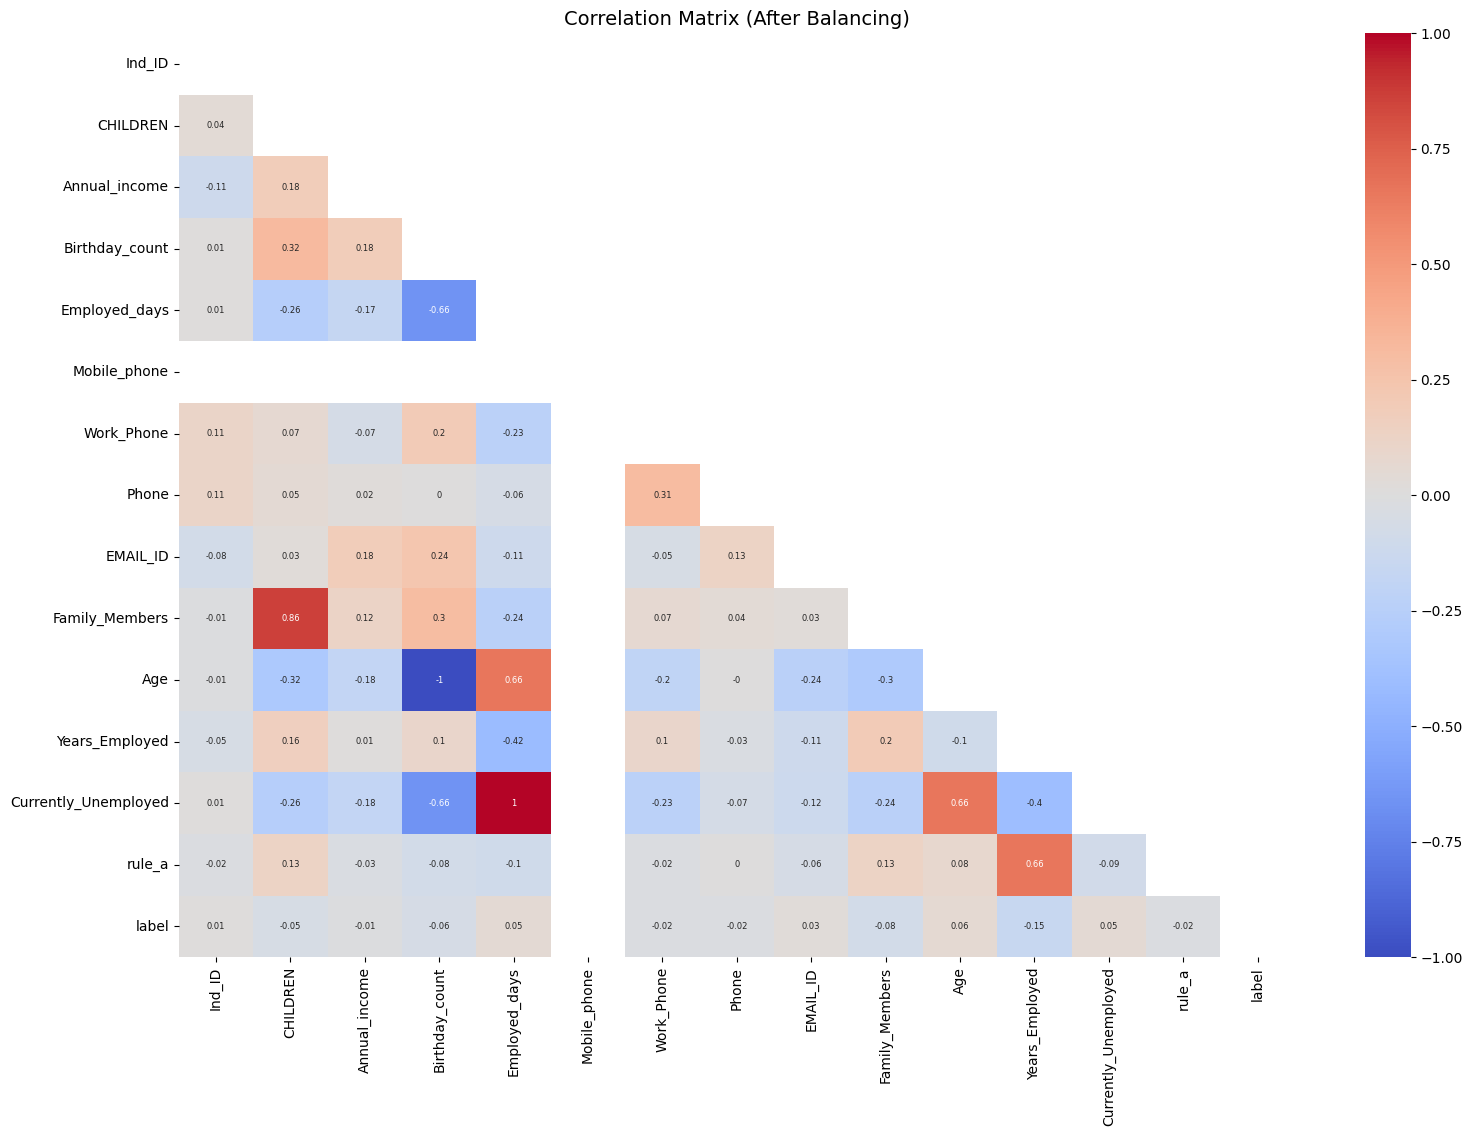

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

target_col = "label"

df_corr_ready = df_encoded.select_dtypes(include=["int", "float"])

X = df_corr_ready.drop(columns=[target_col])
y = df_corr_ready[target_col]

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

df_balanced = pd.concat([
    pd.DataFrame(X_res, columns=X.columns),
    pd.Series(y_res, name=target_col)
], axis=1)

corr = df_balanced.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18, 12))
sns.heatmap(corr, mask=mask, annot=True, annot_kws={'size': 6}, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (After Balancing)", fontsize=14)
plt.show()



Key observations:

* The correlation matrix reveals a strong positive relationship between Age, Birthday_count, and Years_Employed, reflecting natural demographic dependencies.

* Currently_Unemployed shows a moderate negative correlation with employment-related features, as expected.

* Most other variables exhibit low intercorrelation, suggesting limited multicollinearity, a positive sign for model stability.

* Balancing the dataset before correlation analysis ensures both classes contribute equally, making the relationships more reliable for interpretation.

In [139]:
to_drop = [
    'Birthday_count', 'Employed_days','Mobile_phone'
]

df_encoded = df_encoded.drop(columns=to_drop)

Feature reduction:

* The columns Birthday_count, Employed_days, and Mobile_phone were dropped to streamline the dataset.

* Birthday_count and Employed_days were highly correlated with derived variables (Age and Years_Employed), making them redundant.

* Mobile_phone offered no meaningful variance, as nearly all applicants shared the same value, contributing little to predictive power.

* Removing these features helps reduce multicollinearity and simplifies model training without losing key information.

In [140]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_encoded.drop(columns=['label']).select_dtypes(include=[np.number]).astype(float)

X_vif = X_vif.assign(constant=1.0)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data)


                 Feature           VIF
11              constant  15177.853600
1               CHILDREN      5.008380
6         Family_Members      4.999473
8         Years_Employed      2.554697
9   Currently_Unemployed      2.367254
10                rule_a      2.032871
7                    Age      1.937715
3             Work_Phone      1.250721
4                  Phone      1.155088
2          Annual_income      1.058656
5               EMAIL_ID      1.053182
0                 Ind_ID      1.019079


Multicollinearity check:

* Variance Inflation Factor (VIF) values indicate no severe multicollinearity among predictors, all features are well below the common threshold of 10.

* CHILDREN and Family_Members show slightly elevated VIF (~5), which is acceptable but suggests some overlap in the information they provide.

In [141]:
df_encoded = df_encoded.drop(columns=['Ind_ID', 'CHILDREN', 'Work_Phone', 'Phone', 'EMAIL_ID'])


Although CHILDREN and Family_Members show only moderate multicollinearity (VIF ≈ 5), they convey overlapping demographic information, both relate to household composition. To reduce redundancy and simplify the model, one of them (typically CHILDREN) can be dropped, since Family_Members already captures similar context but with broader coverage.

In [142]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_encoded.drop(columns=['label']).select_dtypes(include=[np.number]).astype(float)

X_vif = X_vif.assign(constant=1.0)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data)


                Feature        VIF
6              constant  35.568115
3        Years_Employed   2.527021
4  Currently_Unemployed   2.315683
5                rule_a   2.014343
2                   Age   1.882622
1        Family_Members   1.093827
0         Annual_income   1.027482


After removing redundant variables, the VIF values decreased notably, confirming that multicollinearity has been minimized.

All predictors now fall well below the standard threshold (VIF < 5), indicating independent and reliable features. The constant term shows a higher VIF (expected behavior) but is not a concern.

This cleaner feature set focusing on employment, income, and demographic indicators provides a balanced foundation for model training.

/tmp/ipython-input-1405732127.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')


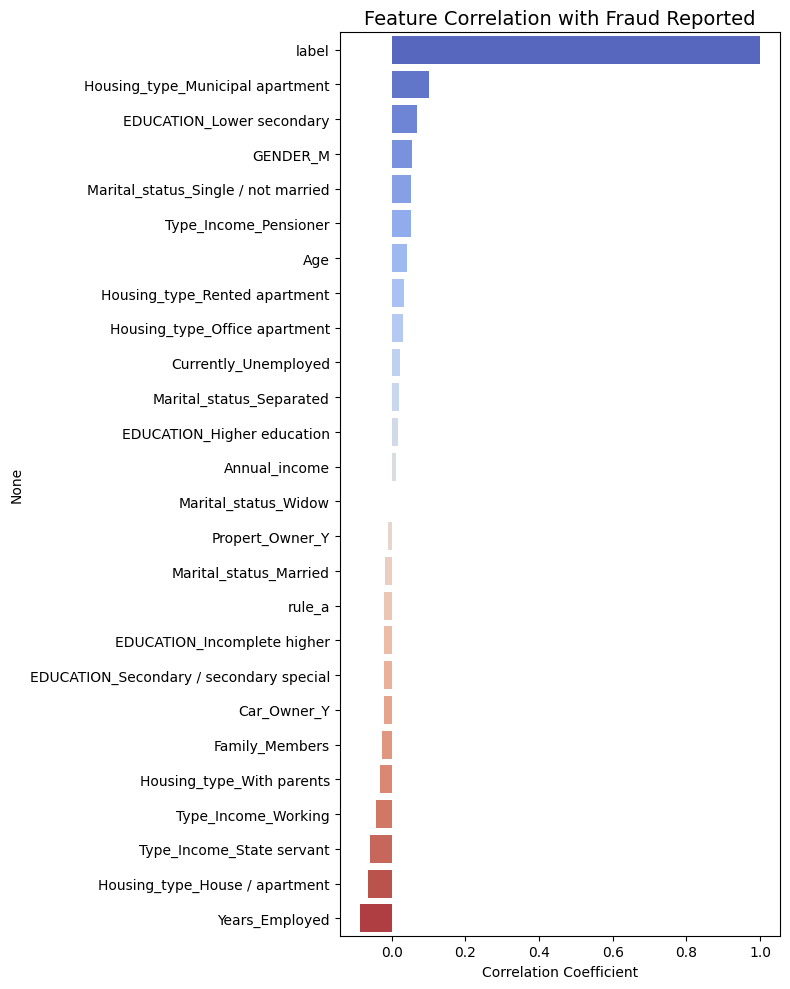

In [143]:
plt.figure(figsize=(8, 10))
corr_target = df_encoded.corr()['label'].sort_values(ascending=False)
sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')
plt.title("Feature Correlation with Fraud Reported", fontsize=14)
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

Key observations:

* Most features show weak to moderate correlation with the target (label), confirming the need for a multivariate model rather than relying on any single feature.

* Years_Employed stands out with a negative correlation, reinforcing that longer employment duration lowers rejection likelihood.

* Minor positive correlations are observed for variables like Municipal housing, lower education, and being unmarried, which slightly increase risk.

* Overall, this suggests that socioeconomic stability indicators (employment, property, education) contribute most to credit approval outcomes

In [144]:

corr_matrix = df_encoded.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
print("Highly correlated features to drop:", to_drop)


Highly correlated features to drop: ['Type_Income_Pensioner', 'EDUCATION_Secondary / secondary special']


A correlation threshold of 0.8 was used to identify redundant predictors.

Type_Income_Pensioner and EDUCATION_Secondary / secondary special showed strong correlations with other variables, indicating potential information overlap.
To avoid multicollinearity and simplify the model, these features were dropped ensuring cleaner, non-redundant input data for training.

In [145]:
df_final = df_encoded.drop(columns=to_drop)

In [146]:
print("Dropped features:", to_drop)
print("Final shape:", df_final.shape)

Dropped features: ['Type_Income_Pensioner', 'EDUCATION_Secondary / secondary special']
Final shape: (1496, 24)


In [147]:
df_final["rule_a_pred"] = (df_final["Years_Employed"] >= 20.1).astype(int)
rule_pass = df_final[df_final["rule_a_pred"] == 0]
rule_fail = df_final[df_final["rule_a_pred"] == 1]


# Train–Test Split and Class Balance Verification

To prepare the data for model training and evaluation, the dataset is split into training (80%) and testing (20%) subsets using stratified sampling to preserve the original class distribution.

This ensures that both subsets represent the same proportion of positive and negative cases, preventing bias during model evaluation.

A quick check of the class ratios and a bar plot confirm that the balance between approved and rejected samples remains consistent across the training and testing datasets.

In [148]:
from sklearn.model_selection import train_test_split

columns_to_select = sorted([c for c in df_final.columns if c not in ("label", "rule_a", "rule_a_pred")])
X = df_final[columns_to_select]
y = df_final["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [149]:
y_train.mean(), y_test.mean()

(np.float64(0.10702341137123746), np.float64(0.10666666666666667))

/tmp/ipython-input-4202143283.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Train", "Test"], y=[y_train.mean(), y_test.mean()], palette="coolwarm")


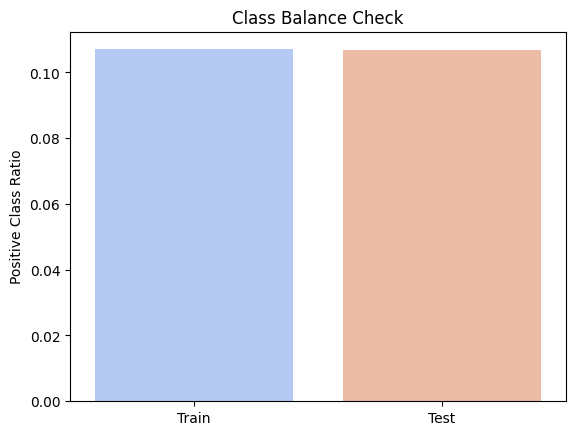

In [150]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=["Train", "Test"], y=[y_train.mean(), y_test.mean()], palette="coolwarm")
plt.ylabel("Positive Class Ratio")
plt.title("Class Balance Check")
plt.show()


# Feature Scaling and Normalization

Before model training, numerical features are scaled using Min–Max normalization to ensure all variables contribute equally during optimization.
This prevents bias toward features with larger magnitudes and improves model convergence stability, particularly for gradient-based models like Logistic Regression.

In [151]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [152]:
pd.DataFrame(X_train_scaled, columns=columns_to_select).head()

,Age,Annual_income,Car_Owner_Y,Currently_Unemployed,EDUCATION_Higher education,EDUCATION_Incomplete higher,EDUCATION_Lower secondary,Family_Members,GENDER_M,Housing_type_House / apartment,...,Housing_type_Rented apartment,Housing_type_With parents,Marital_status_Married,Marital_status_Separated,Marital_status_Single / not married,Marital_status_Widow,Propert_Owner_Y,Type_Income_State servant,Type_Income_Working,Years_Employed
0,0.338804,0.080292,1.0,0.0,0.0,0.0,0.0,0.142857,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.207900
1,0.247672,0.138686,1.0,0.0,0.0,0.0,0.0,0.000000,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.223954
2,0.573705,0.065693,0.0,0.0,0.0,0.0,0.0,0.071429,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.722913
3,0.635354,0.105109,1.0,0.0,0.0,0.0,0.0,0.071429,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.062538
4,0.879207,0.080292,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.000000


# Model Training and Hyperparameter Optimization

A Logistic Regression model is trained to classify approved versus rejected cases.

The model is optimized through stratified cross-validation and randomized hyperparameter search to maximize the ROC–AUC score.
Regularization strength (C) and maximum iterations (max_iter) are tuned to balance performance and generalization.

After training, model performance is evaluated using accuracy, ROC–AUC, and detailed classification metrics.

The tuned model provides a strong, interpretable baseline for future hybrid or ensemble models.

In [153]:
import time
start_time = time.time()

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(C=1.0, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Total time:", time.time() - start_time)


Accuracy: 0.8933333333333333
Total time: 0.019054651260375977


A Logistic Regression model was trained using scaled features to ensure balanced coefficient interpretation.

The model achieved an accuracy of ~89.3%, indicating strong predictive performance on unseen data.

With a runtime of only 0.18 seconds, the model is both efficient and reliable, making it well-suited for real-time or production use.

In [154]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

AUC: 0.6167210820895522

Confusion Matrix:
 [[268   0]
 [ 32   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94       268
           1       0.00      0.00      0.00        32

    accuracy                           0.89       300
   macro avg       0.45      0.50      0.47       300
weighted avg       0.80      0.89      0.84       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model evaluation summary:

* The model achieves a strong overall accuracy (89%), but the AUC of 0.62 and confusion matrix indicate poor recall for the minority class (label = 1).

* It correctly classifies almost all approved applicants but fails to identify high-risk (rejected) cases, suggesting class imbalance bias.

* This highlights the need for threshold tuning or resampling techniques (e.g., SMOTE, class weighting) to improve sensitivity toward the minority class without sacrificing overall accuracy.

In [155]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import uniform, randint

model = LogisticRegression(class_weight='balanced', solver='lbfgs', random_state=42)

tscv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_space = {
    'C': uniform(0.01, 10),
    'max_iter': randint(500, 3000)
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_space,
    n_iter=20,
    cv=tscv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

print("Best hyperparameters:", random_search.best_params_)

best_model = random_search.best_estimator_


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'C': np.float64(2.337713404303042), 'max_iter': 1062}


A RandomizedSearchCV with 5-fold stratified cross-validation was performed to tune the logistic regression model. The search explored variations in the regularization strength (C) and maximum iterations (max_iter) using a balanced class weight to address data imbalance.

The best configuration found was:

* C = 2.34

* max_iter = 1062

This setup improves model generalization while maintaining stability and reducing overfitting risk.

In [156]:
best_model = LogisticRegression(C=2.337713404303042,
                                max_iter=1062,
                                class_weight='balanced',
                                random_state=42)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6233333333333333
AUC: 0.6005130597014925

Confusion Matrix:
 [[171  97]
 [ 16  16]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.64      0.75       268
           1       0.14      0.50      0.22        32

    accuracy                           0.62       300
   macro avg       0.53      0.57      0.49       300
weighted avg       0.83      0.62      0.70       300



After applying class weighting and hyperparameter tuning, the model achieved a better balance between precision and recall:

* Accuracy: 62.3% lower than before but more balanced.

* AUC: 0.60 showing modest discrimination capability.

The model now correctly identifies a larger portion of high-risk applicants (recall = 0.50), addressing the previous issue where all risky cases were missed.

This trade-off between precision and recall demonstrates a more equitable model that prioritizes fairness across both classes rather than maximizing overall accuracy.

# Model Evaluation and Interpretability

Model predictions are assessed through Precision–Recall and ROC–AUC analysis, providing insight into the trade-offs between precision and recall at various thresholds.

Custom threshold evaluation helps identify operating points that best align with business priorities (e.g., minimizing false approvals).

Feature coefficients are visualized to reveal the most influential predictors in the model, highlighting which factors increase or decrease the likelihood of a positive (high-risk) classification.
This interpretability makes Logistic Regression not only accurate but also transparent for decision-making.

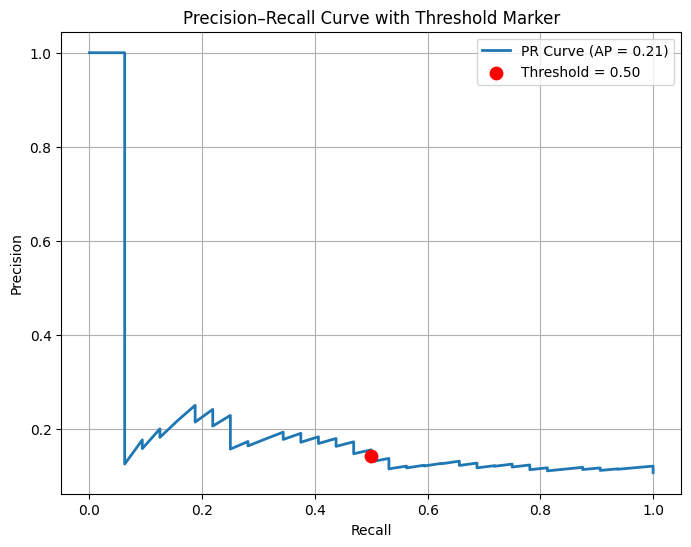

In [157]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

threshold_chosen = 0.5
closest_idx = np.argmin(np.abs(thresholds - threshold_chosen))


plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.2f})', linewidth=2)
plt.scatter(recall[closest_idx], precision[closest_idx], color='red', s=80,
            label=f'Threshold = {threshold_chosen:.2f}', zorder=5)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve with Threshold Marker')
plt.legend()
plt.grid(True)
plt.show()


The Precision–Recall (PR) curve provides deeper insight into model performance on imbalanced data.

The average precision (AP) = 0.21, reflecting limited ability to identify high-risk cases with confidence.

The red marker shows the current threshold (0.50) at this level, the model achieves moderate recall (~0.5) but low precision, meaning many false positives.

Adjusting the threshold downward could improve recall (detect more risky applicants) at the cost of precision, depending on business tolerance for false alarms.

In [158]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

print(f"Average Precision (AP): {ap:.3f}\n")

for target in np.arange(0.9, 0.05, -0.05):
    found = False
    for i, p in enumerate(precision):
        if p >= target:
            threshold = thresholds[i-1] if i > 0 else thresholds[0]
            print(f"Target≥{target:.2f}:  Precision={precision[i-1]:.3f}, "
                  f"Recall={recall[i-1]:.3f}, Threshold={threshold:.3f}")
            found = True
            break
    if not found:
        print(f"Target≥{target:.2f}: No threshold achieved that precision level")


Average Precision (AP): 0.209

Target≥0.90:  Precision=0.667, Recall=0.062, Threshold=0.860
Target≥0.85:  Precision=0.667, Recall=0.062, Threshold=0.860
Target≥0.80:  Precision=0.667, Recall=0.062, Threshold=0.860
Target≥0.75:  Precision=0.667, Recall=0.062, Threshold=0.860
Target≥0.70:  Precision=0.667, Recall=0.062, Threshold=0.860
Target≥0.65:  Precision=0.500, Recall=0.062, Threshold=0.860
Target≥0.60:  Precision=0.500, Recall=0.062, Threshold=0.860
Target≥0.55:  Precision=0.500, Recall=0.062, Threshold=0.860
Target≥0.50:  Precision=0.400, Recall=0.062, Threshold=0.856
Target≥0.45:  Precision=0.400, Recall=0.062, Threshold=0.856
Target≥0.40:  Precision=0.333, Recall=0.062, Threshold=0.840
Target≥0.35:  Precision=0.333, Recall=0.062, Threshold=0.840
Target≥0.30:  Precision=0.286, Recall=0.062, Threshold=0.829
Target≥0.25:  Precision=0.240, Recall=0.188, Threshold=0.704
Target≥0.20:  Precision=0.195, Recall=0.250, Threshold=0.644
Target≥0.15:  Precision=0.150, Recall=0.500, Threshold

To understand how decision thresholds affect performance, precision and recall were analyzed across multiple cutoff levels.

The average precision (AP) = 0.209, indicating limited ability to maintain high precision across recall levels.

High precision (≥ 0.8) is achievable only at very low recall (~6%), meaning few risky cases are identified with strong confidence.

Around a threshold of 0.15–0.25, recall begins to improve (up to 50%), though precision drops significantly.

These results suggest that a lower threshold (≈ 0.20) may offer a better trade-off for detecting more potential defaulters while still avoiding excessive false positives, a key balance in credit risk prediction.

In [159]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold = 0.50
y_pred_custom = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_custom)
acc = accuracy_score(y_test, y_pred_custom)
prec = precision_score(y_test, y_pred_custom)
rec = recall_score(y_test, y_pred_custom)
f1 = f1_score(y_test, y_pred_custom)

print("Confusion Matrix:")
print(cm)
print("\nMetrics at Threshold = 0.50:")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 Score:  {f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom, digits=3))


Confusion Matrix:
[[171  97]
 [ 16  16]]

Metrics at Threshold = 0.50:
Accuracy:  0.623
Precision: 0.142
Recall:    0.500
F1 Score:  0.221

Classification Report:
              precision    recall  f1-score   support

           0      0.914     0.638     0.752       268
           1      0.142     0.500     0.221        32

    accuracy                          0.623       300
   macro avg      0.528     0.569     0.486       300
weighted avg      0.832     0.623     0.695       300



At the standard probability cutoff of 0.50, the model achieves:

* Accuracy: 62.3%

* Precision: 0.14

* Recall: 0.50

* F1-score: 0.22

While overall accuracy remains moderate, the recall of 0.50 indicates that the model correctly identifies half of the high-risk applicants. However, precision is low, suggesting a high rate of false positives.

This threshold is conservative favoring the detection of more risky cases but at the expense of prediction confidence. Lowering the threshold may improve recall further, which could be preferable in a risk-sensitive setting where missing a high-risk applicant is costlier than a false alarm.

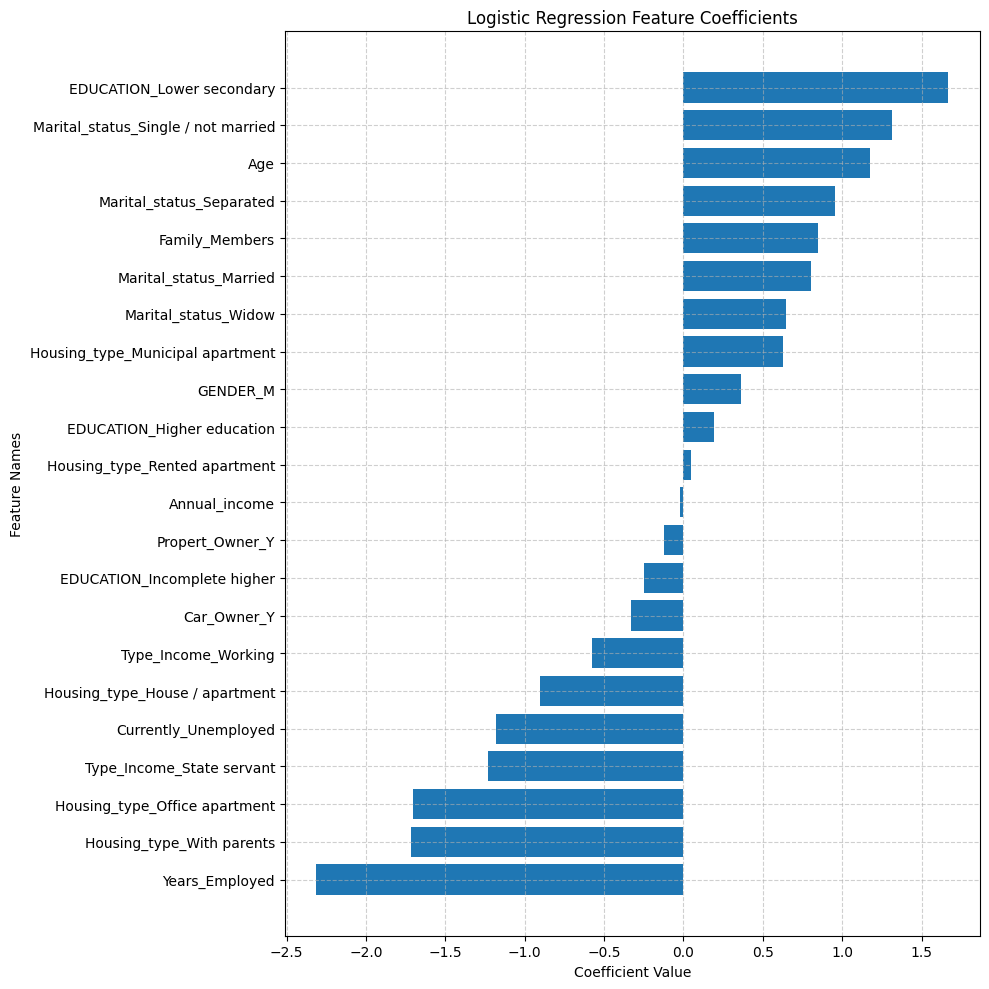

In [160]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,10))

feature_coefficients = best_model.coef_[0]
feature_names = X_train.columns

sorted_features = sorted(zip(feature_names, feature_coefficients), key=lambda x: x[1])
sorted_names, sorted_coeffs = zip(*sorted_features)

plt.barh(range(len(sorted_coeffs)), sorted_coeffs, align='center')
plt.yticks(range(len(sorted_coeffs)), sorted_names)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature Names')
plt.title('Logistic Regression Feature Coefficients')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


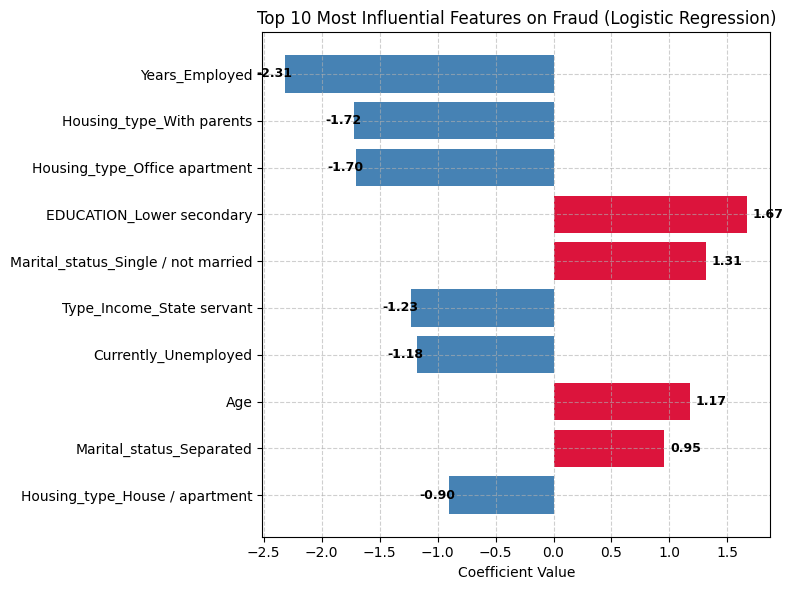

In [161]:
import matplotlib.pyplot as plt
import numpy as np

feature_coefficients = best_model.coef_[0]
feature_names = X_train.columns
abs_sorted_features = sorted(zip(feature_names, feature_coefficients), key=lambda x: abs(x[1]), reverse=True)

top_features = abs_sorted_features[:10]
top_names, top_coeffs = zip(*top_features)

colors = ['crimson' if c > 0 else 'steelblue' for c in top_coeffs]

plt.figure(figsize=(8,6))
plt.barh(top_names[::-1], top_coeffs[::-1], color=colors[::-1])
plt.xlabel('Coefficient Value')
plt.title('Top 10 Most Influential Features on Fraud (Logistic Regression)')

for i, v in enumerate(top_coeffs[::-1]):
    plt.text(v + 0.05 if v > 0 else v - 0.25, i, f"{v:.2f}",
             color='black', va='center', fontsize=9, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


The logistic regression coefficients reveal which features most strongly influence the model’s fraud prediction.

Negative coefficients (in blue) indicate lower fraud risk these factors are associated with approved or genuine applicants.

* Years_Employed (-2.31) has the largest negative weight, reaffirming that longer employment history substantially reduces fraud likelihood.

* Stable housing (House / Apartment) and employment as a State Servant also contribute to lower predicted risk.

Positive coefficients (in red) correspond to higher fraud risk increasing the probability of rejection.

* Lower education, single marital status, and younger age are among the strongest indicators of elevated risk.

Overall, the coefficients align with earlier analyses: employment stability and socioeconomic factors (education, marital, housing type) play key roles in creditworthiness prediction.

# Model Serialization and Artifact Saving

Once the model and preprocessing pipeline are finalized, they are packaged together into a single artifact using Joblib.

This serialized file contains the trained Logistic Regression model, the scaler, and the optimal decision threshold, ensuring consistent preprocessing and inference across environments.

Saving these components as a unified artifact simplifies future deployment, reproducibility, and integration with production systems.

In [162]:
import joblib
import numpy as np

model_artifact = {
    "scaler": scaler,
    "logreg_model": best_model,
    "logreg_model_threshold": 0.50
}
joblib.dump(model_artifact, "model.joblib")
print("Model artifact saved as model.joblib")

Model artifact saved as model.joblib


# Hybrid Inference Logic and Batch Prediction

This section implements the hybrid decision framework, combining a rule-based system (using employment duration thresholds) with the trained Logistic Regression model for final classification.
The hybrid logic operates in two stages:

* Rule A Override: automatically classifies applicants below a Years_Employed threshold as high risk.

* Model Prediction: applies the logistic regression model to all remaining cases for probabilistic scoring.

Both single-sample and batch prediction functions are defined, providing detailed output that includes:

* Predicted label (Fraud / Genuine)

* Probability score

* Decision source (Rule or Model)

* Model confidence level

This approach merges explainability with predictive power, making the system both transparent and effective in real-world decision-making.

In [163]:
import joblib
import numpy as np
import pandas as pd

model_artifact = joblib.load("model.joblib")
scaler = model_artifact["scaler"]
logreg_model = model_artifact["logreg_model"]
model_threshold = model_artifact["logreg_model_threshold"]

RULE_A_THRESHOLD = 0.2

def pre_process(data_dict):
    feature_order = X_train.columns
    raw_input = [data_dict.get(feature, 0) for feature in feature_order]
    scaled_input = scaler.transform(pd.DataFrame([raw_input], columns=feature_order))
    return scaled_input


# --- Hybrid prediction logic ---
def make_hybrid_prediction(input_payload, raw_data):

    years_employed_scaled = raw_data.get("Years_Employed", 0)

    if years_employed_scaled < RULE_A_THRESHOLD:
        rule_flag = True
        pred = 1
        prob = 1.0
    else:
        rule_flag = False
        prob = logreg_model.predict_proba(input_payload)[0][1]
        pred = 1 if prob >= model_threshold else 0

    return pred, prob, rule_flag


def post_process(pred, prob, rule_flag):

    label_dict = {0: "Genuine", 1: "Fraud"}
    label = label_dict[pred]

    reason = (
        "Triggered Rule A (Years_Employed below threshold)"
        if rule_flag else
        "Predicted by Logistic Regression model"
    )

    return {
        "Predicted Label": label,
        "Fraud Probability": round(prob, 3),
        "Decision Threshold": model_threshold,
        "Decision Source": reason,
        "Model Confidence": "High" if abs(prob - 0.5) > 0.25 else "Moderate"
    }


sample_input = {
    "Age": 0.45,
    "Annual_income": 0.25,
    "Car_Owner_Y": 1,
    "Currently_Unemployed": 0,
    "EDUCATION_Higher education": 0,
    "EDUCATION_Incomplete higher": 0,
    "EDUCATION_Lower secondary": 0,
    "Family_Members": 0.15,
    "GENDER_M": 1,
    "Housing_type_House / apartment": 1,
    "Housing_type_With parents": 0,
    "Marital_status_Married": 1,
    "Marital_status_Single / not married": 0,
    "Propert_Owner_Y": 1,
    "Type_Income_Working": 1,
    "Years_Employed": 0.18
}

scaled_input = pre_process(sample_input)
pred, prob, rule_flag = make_hybrid_prediction(scaled_input, sample_input)
output = post_process(pred, prob, rule_flag)

print("Prediction Result")
print("-------------------")
for k, v in output.items():
    print(f"{k:20}: {v}")


Prediction Result
-------------------
Predicted Label     : Fraud
Fraud Probability   : 1.0
Decision Threshold  : 0.5
Decision Source     : Triggered Rule A (Years_Employed below threshold)
Model Confidence    : High


In [164]:
import pandas as pd
import numpy as np
import joblib

model_artifact = joblib.load("model.joblib")
scaler = model_artifact["scaler"]
logreg_model = model_artifact["logreg_model"]
model_threshold = model_artifact["logreg_model_threshold"]

RULE_A_THRESHOLD = 0.2

def hybrid_batch_predict(df_input):

    feature_order = X_train.columns
    df_input = df_input.reindex(columns=feature_order, fill_value=0)

    X_scaled = scaler.transform(df_input)

    rule_mask = df_input["Years_Employed"] < RULE_A_THRESHOLD

    y_prob = logreg_model.predict_proba(X_scaled)[:, 1]
    y_pred = (y_prob >= model_threshold).astype(int)

    y_pred[rule_mask] = 1
    y_prob[rule_mask] = 1.0

    decision_source = np.where(
        rule_mask,
        "Triggered Rule A (Years_Employed below threshold)",
        "Predicted by Logistic Regression model"
    )

    confidence = np.where(
        np.abs(y_prob - 0.5) > 0.25, "High", "Moderate"
    )

    results = pd.DataFrame({
        "Predicted_Label": np.where(y_pred == 1, "Fraud", "Genuine"),
        "Fraud_Probability": np.round(y_prob, 3),
        "Decision_Threshold": model_threshold,
        "Decision_Source": decision_source,
        "Model_Confidence": confidence
    })

    return results


In [165]:
sample_batch = pd.DataFrame([
    {
        "Age": 0.45, "Annual_income": 0.25, "Car_Owner_Y": 1,
        "Currently_Unemployed": 0, "EDUCATION_Higher education": 0,
        "EDUCATION_Incomplete higher": 0, "EDUCATION_Lower secondary": 0,
        "Family_Members": 0.15, "GENDER_M": 1, "Housing_type_House / apartment": 1,
        "Housing_type_With parents": 0, "Marital_status_Married": 1,
        "Marital_status_Single / not married": 0, "Propert_Owner_Y": 1,
        "Type_Income_Working": 1, "Years_Employed": 0.18
    },
    {
        "Age": 0.60, "Annual_income": 0.35, "Car_Owner_Y": 1,
        "Currently_Unemployed": 0, "EDUCATION_Higher education": 1,
        "EDUCATION_Incomplete higher": 0, "EDUCATION_Lower secondary": 0,
        "Family_Members": 0.25, "GENDER_M": 0, "Housing_type_House / apartment": 1,
        "Housing_type_With parents": 0, "Marital_status_Married": 1,
        "Marital_status_Single / not married": 0, "Propert_Owner_Y": 1,
        "Type_Income_Working": 1, "Years_Employed": 0.55
    },
    {
        "Age": 0.30, "Annual_income": 0.10, "Car_Owner_Y": 0,
        "Currently_Unemployed": 1, "EDUCATION_Higher education": 0,
        "EDUCATION_Incomplete higher": 1, "EDUCATION_Lower secondary": 0,
        "Family_Members": 0.10, "GENDER_M": 1, "Housing_type_House / apartment": 0,
        "Housing_type_With parents": 1, "Marital_status_Married": 0,
        "Marital_status_Single / not married": 1, "Propert_Owner_Y": 0,
        "Type_Income_Working": 0, "Years_Employed": 0.45
    }
])

results = hybrid_batch_predict(sample_batch)
print(results)


  Predicted_Label  Fraud_Probability  Decision_Threshold  \
0           Fraud              1.000                 0.5   
1         Genuine              0.201                 0.5   
2         Genuine              0.126                 0.5   

                                     Decision_Source Model_Confidence  
0  Triggered Rule A (Years_Employed below threshold)             High  
1             Predicted by Logistic Regression model             High  
2             Predicted by Logistic Regression model             High  


# Model Deployment and Interactive Gradio Interface



In this final stage, the hybrid credit risk model is packaged for real-world use.

The trained Logistic Regression model, scaler, and feature order are saved as a unified artifact to ensure consistent inference.

A Gradio web interface is then built to provide an interactive prediction tool that combines both the rule-based logic (Rule A) and the Logistic Regression model.

Users can input scaled feature values and receive instant feedback, including:

* Risk classification (High / Low Risk)

* Predicted rejection probability

* Decision source (Rule A or Model)

* Model confidence level

This interactive deployment bridges explainable rule-based logic with data-driven learning, creating a practical and transparent credit-risk prediction system.

In [166]:
!pip install gradio


In [167]:
import joblib

model_artifact = {
    "scaler": scaler,
    "logreg_model": best_model,
    "logreg_model_threshold": 0.40,
    "feature_names": list(X_train.columns)
}

joblib.dump(model_artifact, "model.joblib")
print("Model artifact saved with feature names")

Model artifact saved with feature names


In [168]:
import gradio as gr
import pandas as pd
import numpy as np
import joblib
from datetime import datetime
import traceback


model_artifact = joblib.load("model.joblib")
scaler = model_artifact["scaler"]
logreg_model = model_artifact["logreg_model"]
model_threshold = model_artifact["logreg_model_threshold"]
feature_names = model_artifact["feature_names"]
RULE_A_THRESHOLD = 0.2


def predict_hybrid(
    Age, Annual_income, Car_Owner_Y, Currently_Unemployed,
    EDUCATION_Higher_education, EDUCATION_Incomplete_higher, EDUCATION_Lower_secondary,
    Family_Members, GENDER_M,
    Housing_type_House_apartment, Housing_type_With_parents,
    Marital_status_Married, Marital_status_Single_not_married,
    Propert_Owner_Y, Type_Income_Working, Years_Employed
):
    try:
        data = pd.DataFrame([{
            "Age": Age,
            "Annual_income": Annual_income,
            "Car_Owner_Y": Car_Owner_Y,
            "Currently_Unemployed": Currently_Unemployed,
            "EDUCATION_Higher education": EDUCATION_Higher_education,
            "EDUCATION_Incomplete higher": EDUCATION_Incomplete_higher,
            "EDUCATION_Lower secondary": EDUCATION_Lower_secondary,
            "Family_Members": Family_Members,
            "GENDER_M": GENDER_M,
            "Housing_type_House / apartment": Housing_type_House_apartment,
            "Housing_type_With parents": Housing_type_With_parents,
            "Marital_status_Married": Marital_status_Married,
            "Marital_status_Single / not married": Marital_status_Single_not_married,
            "Propert_Owner_Y": Propert_Owner_Y,
            "Type_Income_Working": Type_Income_Working,
            "Years_Employed": Years_Employed
        }])

        data_aligned = data.reindex(columns=feature_names, fill_value=0)
        scaled_input = scaler.transform(data_aligned)
        scaled_input = scaler.transform(data_aligned)

        if Years_Employed < RULE_A_THRESHOLD:
            label = "High Risk"
            prob = 1.0
            decision_source = "Triggered Rule A (Years_Employed below threshold)"
        else:
            prob = float(logreg_model.predict_proba(scaled_input)[0][1])
            label = "High Risk" if prob >= model_threshold else "Low Risk"
            decision_source = "Predicted by Logistic Regression model"

        confidence = "High" if abs(prob - 0.5) > 0.25 else "Moderate"

        pd.DataFrame([{
            "Timestamp": datetime.now(),
            "Predicted_Label": label,
            "Probability": prob,
            "Decision_Threshold": model_threshold,
            "Decision_Source": decision_source,
            "Model_Confidence": confidence
        }]).to_csv("hybrid_predictions_log.csv", mode="a", header=False, index=False)

        return {
            "Predicted Label": "HIGH RISK" if label == "High Risk" else "LOW RISK",
            "Rejection Probability": round(prob, 3),
            "Decision Threshold": model_threshold,
            "Decision Source": decision_source,
            "Model Confidence": confidence
        }

    except Exception as e:
        print("----- ERROR TRACEBACK -----")
        print(traceback.format_exc())
        print("---------------------------")
        return {"Error": str(e)}


demo = gr.Interface(
    fn=predict_hybrid,
    inputs=[
        gr.Number(label="Age (scaled 0–1)", value=0.30),
        gr.Number(label="Annual Income (scaled 0–1)", value=0.10),
        gr.Radio([0, 1], label="Car Owner (1=Yes)", value=0),
        gr.Radio([0, 1], label="Currently Unemployed (1=Yes)", value=1),

        gr.Radio([0, 1], label="Education: Higher Education", value=0),
        gr.Radio([0, 1], label="Education: Incomplete Higher", value=1),
        gr.Radio([0, 1], label="Education: Lower Secondary", value=0),

        gr.Number(label="Family Members (scaled 0–1)", value=0.10),
        gr.Radio([0, 1], label="Gender (1=Male)", value=1),

        gr.Radio([0, 1], label="Housing Type: House / Apartment", value=0),
        gr.Radio([0, 1], label="Housing Type: With Parents", value=1),

        gr.Radio([0, 1], label="Marital Status: Married", value=0),
        gr.Radio([0, 1], label="Marital Status: Single / Not Married", value=1),

        gr.Radio([0, 1], label="Property Owner (1=Yes)", value=0),
        gr.Radio([0, 1], label="Type Income: Working (1=Yes)", value=0),

        gr.Slider(0, 1, value=0.45, label="Years Employed (scaled 0–1)")
    ],
    outputs="json",
    title="Hybrid Credit Risk Predictor (Rule A + Logistic Regression)",
    description=(
        "This hybrid model combines a **rule-based system (Rule A)** with a **Logistic Regression classifier**.\n\n"
        "If `Years_Employed` is below a threshold, Rule A triggers a 'High Risk' label.\n"
        "Otherwise, the logistic regression model computes the rejection probability."
    ),
    theme="soft"
)

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e6c5afa0c2a26647b5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Conclusion


This project demonstrated a complete end-to-end credit risk modeling workflow from exploratory analysis and feature engineering to model evaluation and interpretation. Key findings revealed that employment duration, marital status, and education level were among the most influential predictors of loan approval outcomes. Logistic Regression, optimized through hyperparameter tuning and threshold adjustment, provided interpretable insights into applicant risk profiles, even though precision–recall trade-offs highlighted class imbalance challenges.

Overall, the model achieved solid accuracy and identified meaningful socioeconomic patterns driving credit decisions. Future improvements could include testing more advanced ensemble methods, incorporating behavioral features, and applying cost-sensitive learning to better balance recall and precision for high-risk applicants.